## Preliminary
### 1. Create a class for Markov Decision Processes (MDPs) that takes advantage of how you defined Markov Reward Processes

This solution can be found in src/finite_mdp.py

S size: 95
A: {'forward', 'right', 'left'}
terminal_states: {'exit', 'crash'}

Transitions from (0,3) with 'forward': {(1, 2): 0.2, (1, 4): 0.2, (1, 1): 0.04800000000000001, (1, 5): 0.04800000000000001, (1, 3): 0.504}
Transitions from (0,3) with 'left': {(0, 1): 0.6324555320336759, (0, 2): 0.3675444679663241}
Transitions from (0,3) with 'right': {(0, 5): 0.6324555320336759, (0, 4): 0.3675444679663241}
Policy Iteration: 1
Policy Iteration: 2
Policy Iteration: 3
Policy Iteration: 4
Policy Iteration: 5
Policy Iteration: 6
Policy Iteration: 7
Policy Iteration: 8
Policy Iteration: 9
Policy Iteration: 10
Policy Iteration: 11
Policy Iteration: 12
Policy Iteration: 13
Policy Iteration: 14
Policy Iteration: 15
Policy Iteration: 16
Policy Iteration: 17
Policy Iteration: 18
Policy Iteration: 19
Policy Iteration: 20
Policy Iteration: 21



Optimal policy sample:
(0,1): right  (0,2): right  (0,3): forward  (0,4): left  (0,5): left  
(1,1): right  (1,2): right  (1,3): forward  (1,4): left  (1,5): left  
(2,1): right  (2,2): right  (2,3): forward  (2,4): left  (2,5): left  
(3,1): right  (3,2): right  (3,3): forward  (3,4): left  (3,5): left  
(4,1): right  (4,2): right  (4,3): forward  (4,4): left  (4,5): left  

Total states in policy: 97
Action distribution: {'left': 33, 'right': 33, 'forward': 29}


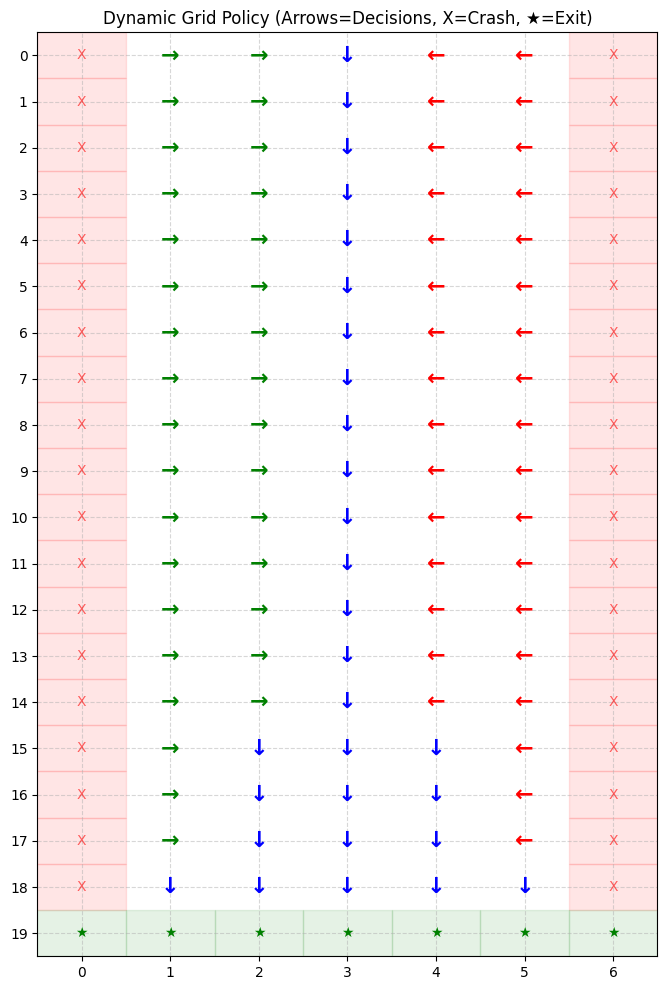

In [1]:
from src.p1.helpers import generate_grid
from src.utils.grid_environment import GridEnvironment
from src.utils.value_convergence import policy_iteration
from src.p1.helpers import visualize_policy
from IPython.display import display
from src.utils.heatmap_animation import show_heatmap_animation_matplotlib


# Set parameters for the grid world
grid_size = (20, 7)
reward_range = [-1, -1]
gamma = 0.99
step_penalty = -1
random_transition_type = "m2p1"
random_probability = 0.4 # wind chance
start_state = (0, 3)
# Create the action map
action_map = {
    "forward": (1, 0), 
    "left": (0, -1), 
    "right": (0, 1)
}
# Create the terminal map
terminal_map = {
    "crash": -20,
    "exit": 100
}

# Generate the grid for the environment
grid = generate_grid(
    grid_size=grid_size,
    reward_range=reward_range,
    terminal_state_values=list(terminal_map.values())
)

# Initialize the environment
chasm_env = GridEnvironment(
    curr_grid=grid,
    reward_range=reward_range,
    terminal_map=terminal_map,
    action_map=action_map,
    gamma=gamma,
    step_penalty=step_penalty,
    random_transition_type=random_transition_type,
    random_probability=random_probability,
    start_state=start_state
)

# Run policy iteration
V, policy = policy_iteration(
    chasm_env,
)

# Create the animation for the value convergence
anim = show_heatmap_animation_matplotlib(
    image_dir="heatmaps",
    fps=6
)

display(anim)

# Print the optimal policy
print("\nOptimal policy sample:")
for i in range(5):
    for j in range(7):
        if (i, j) in policy:
            print(f"({i},{j}): {policy[(i,j)]}", end="  ")
    print()
print(f"\nTotal states in policy: {len(policy)}")

# Count actions
action_counts = {}
for s, a in policy.items():
    if isinstance(s, tuple):
        action_counts[a] = action_counts.get(a, 0) + 1
print(f"Action distribution: {action_counts}")

# Visualize the policy
visualize_policy(grid_size, policy, mask=grid)

